# P00 — Python & NumPy for ML  *(Day One: the mind opens its eyes)*

> **The story so far.** This is the very beginning. We are going to *raise a mind* — grow it,
> over this whole playbook, from nothing into a machine that can read, reason, and write. And on
> day one, our newborn mind opens its eyes and sees… no colours, no words, no faces. It sees
> **numbers**. A photo? A grid of numbers. A sentence? A list of numbers. A sound? Numbers over
> time. Every single thought this mind will ever have is just numbers being multiplied and added,
> fast.

So before "machine learning" can mean anything, we need the thing that holds and moves numbers in
bulk: **NumPy** — the library for fast arrays of numbers. A neural network is *millions of numbers*
being multiplied and added; NumPy (and later PyTorch, which copies its style exactly) is how we
hold and move them. Learn NumPy and you've learned the native language of the entire field.

**The one promise for this whole playbook** (same as Notebook 00): we never hand-wave. Every idea
is shown three ways —

> 1. **Plain words** — what it does and *why the mind needs it*.
> 2. **A tiny worked example BY HAND** — real small numbers, every step written out.
> 3. **Code that re-computes the same numbers** — so the hand answer is *verified*, not trusted.

You only need a little Python. This notebook gives you exactly that little, then the NumPy that the
rest of the journey leans on: **arrays, shape, indexing, vectorisation, broadcasting, and reductions
(sum/mean along an axis)**. Run each code cell right after reading the text above it and check the
printed numbers match the hand calculation — that habit, *verify everything*, is the whole game.

## A1 — The 5% of Python we actually use

You do **not** need to be a Python expert. Across the entire playbook we reuse the same handful
of things: variables, lists, `for` loops, functions, and f-strings for printing. Here they are
in one cell. Read the comments; predict each printed line before you run it.

In [1]:
# variables hold values; Python figures out the type for you
name = "TinyGPT"          # a string (text)
dim  = 4                  # an int (whole number)
lr   = 0.01               # a float (decimal) — "learning rate" shows up everywhere later

# a list is an ordered, editable collection
scores = [2.0, 1.0, 0.0]
print("list:", scores, "| first:", scores[0], "| last:", scores[-1], "| length:", len(scores))

# a for-loop walks through a collection; enumerate also gives the position
for i, s in enumerate(scores):
    print(f"  position {i} holds {s}")     # f-string: {expr} is substituted in

# a function packages reusable logic (def NAME(inputs): ... return output)
def add(a, b):
    return a + b
print("add(2, 3) =", add(2, 3))

# a dict maps keys -> values (we use it for vocabularies: word -> id)
vocab = {"hello": 0, "world": 1}
print("dict:", vocab, "| id of 'world':", vocab["world"])

list: [2.0, 1.0, 0.0] | first: 2.0 | last: 0.0 | length: 3
  position 0 holds 2.0
  position 1 holds 1.0
  position 2 holds 0.0
add(2, 3) = 5
dict: {'hello': 0, 'world': 1} | id of 'world': 1


That is genuinely enough Python. Everything heavy is done by NumPy, which we start now.

## A2 — The NumPy array: a list, but built for math

A Python list can hold anything, which makes it flexible but **slow** and clumsy for math:
`[1,2,3] * 2` gives `[1,2,3,1,2,3]` (it repeats the list!), not `[2,4,6]`. For ML we want the
*mathematical* answer. A **NumPy array** is a grid of numbers of one type, and math on it works
element-by-element the way you expect.

**Worked example by hand.** Take `a = [1, 2, 3]`.
```
a * 2     = [1*2, 2*2, 3*2]   = [2, 4, 6]
a + 10    = [1+10, 2+10, 3+10]= [11, 12, 13]
a + a     = [1+1, 2+2, 3+3]   = [2, 4, 6]
```
Every operation hits each element separately. That's the whole point — it lets us write one
short line that secretly does thousands of multiplications.

In [2]:
import numpy as np                 # the universal alias — everyone writes np

py_list = [1, 2, 3]
a = np.array([1, 2, 3])            # turn a list into a NumPy array

print("python list * 2 :", py_list * 2, "  <- repeats! not what we want")
print("numpy array * 2 :", a * 2,       "  <- math, hand answer [2 4 6]")
print("a + 10          :", a + 10,      "  <- hand [11 12 13]")
print("a + a           :", a + a,       "  <- hand [2 4 6]")
print("type            :", type(a), "| dtype (number kind):", a.dtype)

python list * 2 : [1, 2, 3, 1, 2, 3]   <- repeats! not what we want
numpy array * 2 : [2 4 6]   <- math, hand answer [2 4 6]
a + 10          : [11 12 13]   <- hand [11 12 13]
a + a           : [2 4 6]   <- hand [2 4 6]
type            : <class 'numpy.ndarray'> | dtype (number kind): int32


## A3 — Shape: the single most important property of an array

Almost every bug in ML is a **shape** bug. The shape tells you how many numbers there are and how
they're arranged. Read shapes obsessively.

- a **scalar** is a single number — shape `()`
- a **vector** is a 1-D list of numbers — shape `(n,)`   *(one word's embedding looks like this)*
- a **matrix** is a 2-D grid — shape `(rows, cols)`   *(a batch of word-vectors, or a weight layer)*
- a **3-D tensor** — shape `(a, b, c)`   *(e.g. batch × sequence × features, as in a real GPT)*

**Worked example by hand.** The grid
```
M = [ 1  2  3 ]      <- row 0
    [ 4  5  6 ]      <- row 1
```
has **2 rows** and **3 columns**, so `shape = (2, 3)`, and it holds `2 × 3 = 6` numbers.

In [3]:
import numpy as np
s = np.array(7.0)                       # scalar
v = np.array([1.0, 2.0, 3.0])           # vector
M = np.array([[1, 2, 3],
              [4, 5, 6]])               # matrix, 2 rows x 3 cols
T = np.zeros((2, 3, 4))                 # 3-D tensor of zeros

for name, x in [("scalar s", s), ("vector v", v), ("matrix M", M), ("tensor T", T)]:
    print(f"{name:9} shape={str(x.shape):10} ndim={x.ndim}  total numbers={x.size}")

print("\nM has shape", M.shape, "-> hand said (2, 3) holding 6 numbers")

scalar s  shape=()         ndim=0  total numbers=1
vector v  shape=(3,)       ndim=1  total numbers=3
matrix M  shape=(2, 3)     ndim=2  total numbers=6
tensor T  shape=(2, 3, 4)  ndim=3  total numbers=24

M has shape (2, 3) -> hand said (2, 3) holding 6 numbers


## A4 — Indexing and slicing: grabbing the numbers you want

Counting starts at **0**. For a matrix you give `[row, column]`. A colon `:` means "everything
along this axis", which lets you pull whole rows or columns.

**Worked example by hand** on
```
        col0 col1 col2
row0 [   1    2    3  ]
row1 [   4    5    6  ]
```
```
M[0, 0]  = 1          (row 0, col 0)
M[1, 2]  = 6          (row 1, col 2)
M[0]     = [1, 2, 3]  (all of row 0)
M[:, 1]  = [2, 5]     (column 1 from every row)
M[1, :2] = [4, 5]     (row 1, columns 0 and 1 — the stop index 2 is excluded)
```

In [4]:
import numpy as np
M = np.array([[1, 2, 3],
              [4, 5, 6]])

print("M[0,0]  =", M[0, 0],  " (hand 1)")
print("M[1,2]  =", M[1, 2],  " (hand 6)")
print("M[0]    =", M[0],     " (hand [1 2 3])")
print("M[:,1]  =", M[:, 1],  " (hand [2 5] — column 1)")
print("M[1,:2] =", M[1, :2], " (hand [4 5] — stop index excluded)")

M[0,0]  = 1  (hand 1)
M[1,2]  = 6  (hand 6)
M[0]    = [1 2 3]  (hand [1 2 3])
M[:,1]  = [2 5]  (hand [2 5] — column 1)
M[1,:2] = [4 5]  (hand [4 5] — stop index excluded)


## A5 — Vectorisation: why we *never* write the loop

When your phone brightens a dark photo, it doesn't crawl pixel-by-pixel in slow motion — it adds a
number to a whole array of brightness values in one stroke. The mind learns the same trick. You
*could* add two vectors with a Python `for` loop. You should not. The same operation written as a
single array expression is both shorter and ~100× faster, because NumPy runs the loop in optimised
C under the hood. This habit — "speak to the whole array in one breath, don't loop" — is called
**vectorisation**, and it is how all of deep learning is written.

**Worked example by hand.** `a = [1,2,3]`, `b = [10,20,30]`:
```
loop:        out[0]=1+10=11, out[1]=2+20=22, out[2]=3+30=33  -> [11,22,33]
vectorised:  a + b                                            -> [11,22,33]   (identical)
```
The cell below proves the answers match **and** times both so you can see the speed gap on a
large array.

In [5]:
import numpy as np, time

a = np.array([1, 2, 3])
b = np.array([10, 20, 30])

# the loop way (don't do this in real code)
out = np.zeros(3, dtype=int)
for i in range(3):
    out[i] = a[i] + b[i]
print("loop result       :", out)
print("vectorised a + b  :", a + b, " <- identical, hand [11 22 33]")

# now feel the speed difference on a big array
N = 1_000_000
x = np.arange(N); y = np.arange(N)

t = time.perf_counter()
slow = [x[i] + y[i] for i in range(N)]          # python loop
t_loop = time.perf_counter() - t

t = time.perf_counter()
fast = x + y                                    # vectorised
t_vec = time.perf_counter() - t

print(f"\nadding {N:,} numbers")
print(f"  python loop : {t_loop*1000:8.1f} ms")
print(f"  vectorised  : {t_vec*1000:8.1f} ms   (~{t_loop/max(t_vec,1e-9):.0f}x faster)")

loop result       : [11 22 33]
vectorised a + b  : [11 22 33]  <- identical, hand [11 22 33]



adding 1,000,000 numbers
  python loop :    188.3 ms
  vectorised  :      2.0 ms   (~92x faster)


## A6 — Reductions and the `axis`: sum / mean over rows vs columns

A **reduction** collapses many numbers into fewer — `sum`, `mean`, `max`. The tricky part is the
`axis` argument, which decides *which direction* you collapse. This trips everyone up once, so
nail it now with a picture.

For a 2-D matrix:
- `axis=0` collapses **down the rows** → one number per **column**.
- `axis=1` collapses **across the columns** → one number per **row**.

**Worked example by hand** on
```
        col0 col1 col2
row0 [   1    2    3  ]
row1 [   4    5    6  ]
```
```
M.sum()         = 1+2+3+4+5+6 = 21                 (everything)
M.sum(axis=0)   = [1+4, 2+5, 3+6] = [5, 7, 9]      (one per column)
M.sum(axis=1)   = [1+2+3, 4+5+6]  = [6, 15]        (one per row)
M.mean(axis=1)  = [6/3, 15/3]     = [2.0, 5.0]     (row averages)
```
You will use `axis=-1` (the *last* axis) constantly later — e.g. softmax sums over the vocabulary,
which is always the last axis.

In [6]:
import numpy as np
M = np.array([[1, 2, 3],
              [4, 5, 6]])

print("M.sum()        =", M.sum(),        " (hand 21)")
print("M.sum(axis=0)  =", M.sum(axis=0),  " (hand [5 7 9]  — one per column)")
print("M.sum(axis=1)  =", M.sum(axis=1),  " (hand [6 15]   — one per row)")
print("M.mean(axis=1) =", M.mean(axis=1), " (hand [2. 5.])")
print("M.max(axis=0)  =", M.max(axis=0),  " (hand [4 5 6])")
print("\naxis=-1 means 'last axis'; here that equals axis=1:", np.array_equal(M.sum(axis=-1), M.sum(axis=1)))

M.sum()        = 21  (hand 21)
M.sum(axis=0)  = [5 7 9]  (hand [5 7 9]  — one per column)
M.sum(axis=1)  = [ 6 15]  (hand [6 15]   — one per row)
M.mean(axis=1) = [2. 5.]  (hand [2. 5.])
M.max(axis=0)  = [4 5 6]  (hand [4 5 6])

axis=-1 means 'last axis'; here that equals axis=1: True


### 📊 Step 4 — See it & play with it: which way does `axis` collapse?

This is the picture that fixes `axis` forever. The grid shows the matrix. `axis=0` collapses **down
the rows** (the vertical arrows), leaving **one number per column**. `axis=1` collapses **across the
columns** (the horizontal arrows), leaving **one number per row**. The result is drawn beside the
grid so you can see *which* numbers got added.

**▶ Run the cell and flip the `axis` slider** (0 vs 1) and try `sum`/`mean`/`max` — watch the arrows
turn and the result land on the matching edge. Remember: **axis is the dimension that disappears.**

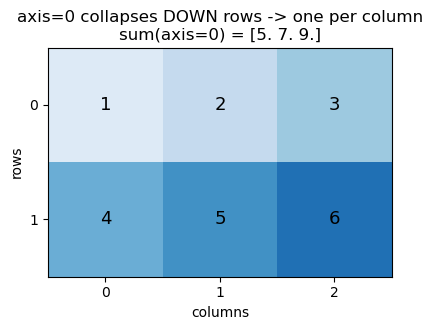

interactive(children=(IntSlider(value=0, description='axis', max=1), Dropdown(description='op', options=('sum'…

In [7]:
import numpy as np, matplotlib.pyplot as plt
from ipywidgets import interact, Dropdown, IntSlider

def show_axis(axis=0, op="sum"):
    M = np.array([[1, 2, 3],
                  [4, 5, 6]], float)
    fn = {"sum": np.sum, "mean": np.mean, "max": np.max}[op]
    result = fn(M, axis=axis)
    fig, ax = plt.subplots(figsize=(5.2, 3.4))
    ax.imshow(M, cmap="Blues", vmin=0, vmax=8)
    for i in range(2):
        for j in range(3):
            ax.text(j, i, int(M[i, j]), ha="center", va="center", fontsize=13)
    # arrows showing the collapse direction
    if axis == 0:
        for j in range(3): ax.annotate("", xy=(j,1.6), xytext=(j,-0.6), arrowprops=dict(arrowstyle="->",color="crimson"))
        ax.set_title(f"axis=0 collapses DOWN rows -> one per column\n{op}(axis=0) = {np.round(result,2)}")
    else:
        for i in range(2): ax.annotate("", xy=(2.6,i), xytext=(-0.6,i), arrowprops=dict(arrowstyle="->",color="crimson"))
        ax.set_title(f"axis=1 collapses ACROSS columns -> one per row\n{op}(axis=1) = {np.round(result,2)}")
    ax.set_xticks(range(3)); ax.set_yticks(range(2)); ax.set_xlabel("columns"); ax.set_ylabel("rows")
    plt.tight_layout(); plt.show()

show_axis(axis=0, op="sum")                                 # static picture (always visible)
interact(show_axis,                                         # ▶ live controls (use them in your IDE)
         axis=IntSlider(min=0, max=1, step=1, value=0, description="axis"),
         op=Dropdown(options=["sum","mean","max"], value="sum", description="op"));

## A7 — Broadcasting: NumPy's most useful (and confusing) trick

**Broadcasting** lets arrays of *different but compatible* shapes combine, by NumPy automatically
"stretching" the smaller one. We already used it: `a + 10` stretched the scalar `10` to every
element. The real power is adding a **vector to every row of a matrix** — exactly what adding a
bias `b` to a layer's output does (Notebook 00, B4).

**The rule:** line the shapes up from the **right**. Two dimensions are compatible if they are
**equal** or one of them is **1**. A size-1 (or missing) dimension is repeated to match.

**Worked example by hand.** Matrix `(2,3)` plus row-vector `(3,)`:
```
M = [ 1  2  3 ]        b = [10, 20, 30]
    [ 4  5  6 ]
                  b is added to EVERY row:
M + b = [ 1+10  2+20  3+30 ]   = [ 11  22  33 ]
        [ 4+10  5+20  6+30 ]     [ 14  25  36 ]
```
And a column-vector `(2,1)` broadcasts the other way — across every column:
```
c = [[100],     M + c = [ 1+100  2+100  3+100 ]   = [ 101 102 103 ]
     [200]]             [ 4+200  5+200  6+200 ]     [ 204 205 206 ]
```

In [8]:
import numpy as np
M = np.array([[1, 2, 3],
              [4, 5, 6]])
b = np.array([10, 20, 30])          # shape (3,) -> added to every row
c = np.array([[100], [200]])        # shape (2,1) -> added to every column

print("M + b (row vector broadcast across rows):")
print(M + b, "\n  hand [[11 22 33],[14 25 36]]\n")
print("M + c (column vector broadcast across columns):")
print(M + c, "\n  hand [[101 102 103],[204 205 206]]")

# a broadcast that FAILS, so you recognise the error later:
try:
    _ = M + np.array([1, 2])        # (2,3) + (2,) -> right-aligned 3 vs 2, neither is 1
except ValueError as e:
    print("\nshape mismatch raises:", e)

M + b (row vector broadcast across rows):
[[11 22 33]
 [14 25 36]] 
  hand [[11 22 33],[14 25 36]]

M + c (column vector broadcast across columns):
[[101 102 103]
 [204 205 206]] 
  hand [[101 102 103],[204 205 206]]

shape mismatch raises: operands could not be broadcast together with shapes (2,3) (2,) 


### 📊 Step 4 — See it & play with it: watch the small array get *stretched*

Broadcasting is easiest to believe when you see it. Below: the matrix `M`, the row-vector `b`
**stretched** (copied down) to match `M`'s shape, and the sum `M + b`. The middle grid is what NumPy
*pretends* `b` looks like — the same row repeated — which is exactly how a bias is added to every row
of a layer's output (Notebook 00, B4).

**▶ Run the cell and edit `b`'s three values** with the sliders — every row of the result shifts by
the same amounts. (Set them to a layer's bias and you're literally watching `Wx + b`.)

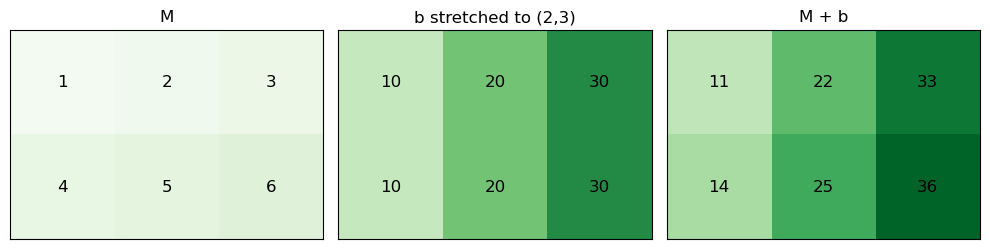

interactive(children=(FloatSlider(value=10.0, description='b[0]', max=30.0, step=5.0), FloatSlider(value=20.0,…

In [9]:
import numpy as np, matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

def show_broadcast(b0=10.0, b1=20.0, b2=30.0):
    M = np.array([[1, 2, 3],
                  [4, 5, 6]], float)
    b = np.array([b0, b1, b2])
    stretched = np.broadcast_to(b, M.shape)                 # what NumPy pretends b is
    result = M + b
    grids = [("M", M), ("b stretched to (2,3)", stretched), ("M + b", result)]
    fig, axes = plt.subplots(1, 3, figsize=(10, 3))
    for ax, (title, G) in zip(axes, grids):
        ax.imshow(G, cmap="Greens", vmin=0, vmax=max(40, result.max()))
        for i in range(G.shape[0]):
            for j in range(G.shape[1]):
                ax.text(j, i, f"{G[i,j]:.0f}", ha="center", va="center", fontsize=12)
        ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout(); plt.show()

show_broadcast()                                            # static picture (always visible)
interact(show_broadcast,                                    # ▶ live sliders (drag them in your IDE)
         b0=FloatSlider(min=0, max=30, step=5, value=10, description="b[0]"),
         b1=FloatSlider(min=0, max=30, step=5, value=20, description="b[1]"),
         b2=FloatSlider(min=0, max=30, step=5, value=30, description="b[2]"));

That error message — *"operands could not be broadcast together"* — is one you will meet often.
When you do: print the `.shape` of both sides and line them up from the right. One of the mismatched
dimensions must be `1` (or absent) for broadcasting to work.

## A8 — Reshape: same numbers, new arrangement

`reshape` rearranges the *same* numbers into a new shape (the total count must stay equal). This
matters because layers expect specific shapes — e.g. flattening an image into a vector, or
splitting a vector into multiple attention "heads" later.

**Worked example by hand.** The 6 numbers `[0,1,2,3,4,5]` can become a `(2,3)` grid by filling
**row by row**:
```
reshape to (2,3):  [ 0  1  2 ]
                   [ 3  4  5 ]
```
`-1` means "you figure out this dimension": `reshape(3, -1)` on 6 numbers gives `(3, 2)`.

In [10]:
import numpy as np
x = np.arange(6)                     # [0 1 2 3 4 5]
print("x          :", x, "shape", x.shape)
print("reshape(2,3):"); print(x.reshape(2, 3), "  <- filled row by row")
print("reshape(3,-1) shape:", x.reshape(3, -1).shape, " (-1 inferred as 2)")
print("flatten back:", x.reshape(2, 3).reshape(-1))

x          : [0 1 2 3 4 5] shape (6,)
reshape(2,3):
[[0 1 2]
 [3 4 5]]   <- filled row by row
reshape(3,-1) shape: (3, 2)  (-1 inferred as 2)
flatten back: [0 1 2 3 4 5]


## Recap — the NumPy you now own

| Idea | Operation | Why it matters later |
|------|-----------|----------------------|
| Array | `np.array([...])` | the container for all weights & data |
| Shape | `x.shape` | reading shapes prevents 90% of bugs |
| Element-wise math | `a + b`, `a * 2` | activations, residual adds |
| Indexing | `M[1, 2]`, `M[:, 0]` | embedding lookups, slicing batches |
| Vectorisation | whole-array expressions | speed; the way DL is written |
| Reduction | `M.sum(axis=...)` | softmax, loss averaging |
| Broadcasting | `M + b` | adding a bias to every row |
| Reshape | `x.reshape(...)` | flattening, splitting heads |

## Common mistakes
1. **Forgetting arrays are element-wise** — `a * b` is *not* matrix multiply (that's `@`, in P01).
2. **Guessing `axis`** — `axis=0` collapses columns-wise (down rows); `axis=1` collapses row-wise. Print to check.
3. **Ignoring shapes until something breaks** — print `.shape` *before* an operation, not after the crash.
4. **Writing Python loops over arrays** — almost always replaceable by one vectorised line.
5. **Assuming reshape copies/reorders cleverly** — it just refills the same numbers in order.

## Exercises (do them in new code cells)
1. Make `a = np.array([2, 4, 6])`. Predict, then check, `a / 2`, `a ** 2`, and `a - a`.
2. Build the matrix `[[1,2],[3,4],[5,6]]`. What is its shape? Get column 1 with a slice.
3. For that matrix, compute the sum down each column and the mean across each row by hand, then verify with `axis`.
4. Add the bias `[100, 200]` to every **row** of a `(3, 2)` matrix using broadcasting. (Hint: what shape must the bias be?)
5. Reshape `np.arange(12)` into `(3, 4)`, then into `(2, 2, 3)`. How many numbers are in each? Do they match?

---

**The mind can now hold and move numbers.** That's the alphabet. Next, in
[P01 — Linear Algebra by hand](P01_Linear_Algebra.ipynb), it gets its very first *sense*: the
**dot product** — a way to feel how much two things agree, answered in a single number — along with
matrix multiplication, the actual operation inside a neural-network layer. Same hand-then-verify
treatment, all the way up. The journey to a thinking machine starts with the next cell.